In [ ]:
#Working with Text Data

In [2]:
from http.client import responses
from importlib.metadata import version

import requests
from sympy.printing.codeprinter import requires

print("torch version:", version("torch"))
print("tiktoken version:", version("tiktoken"))

torch version: 2.11.0
tiktoken version: 0.14.0


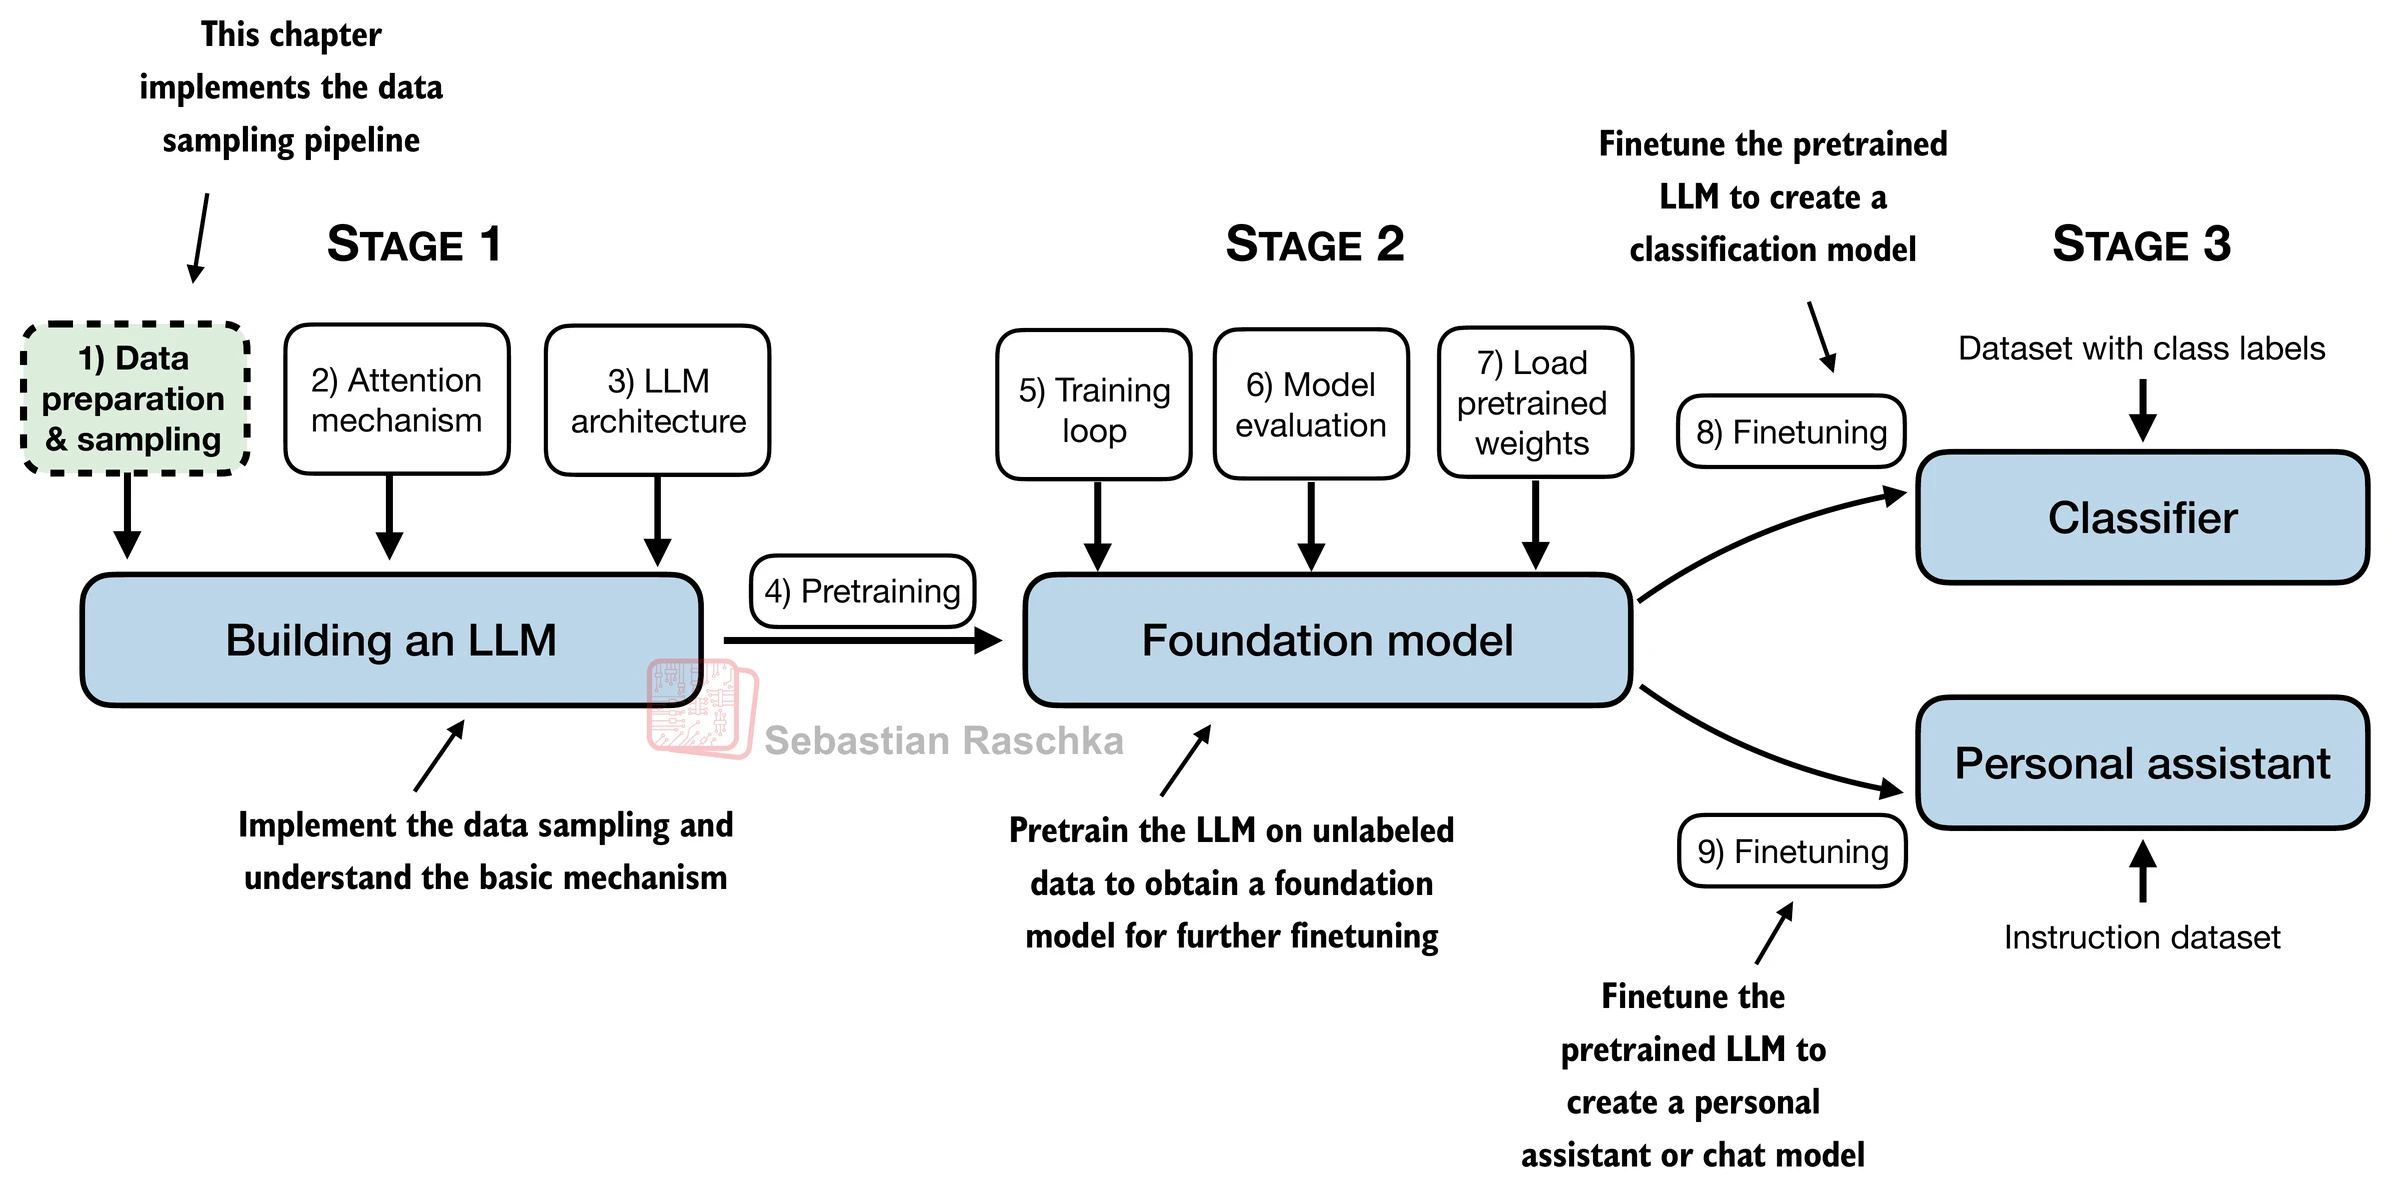

In [1]:
#Understanding word embeddings
# LLMs work with embeddings in high-dimensional spaces (i.e., thousands of dimensions)
# Since we can't visualize such high-dimensional spaces (we humans think in 1, 2, or 3 dimensions), the figure below illustrates a 2-dimensional embedding space

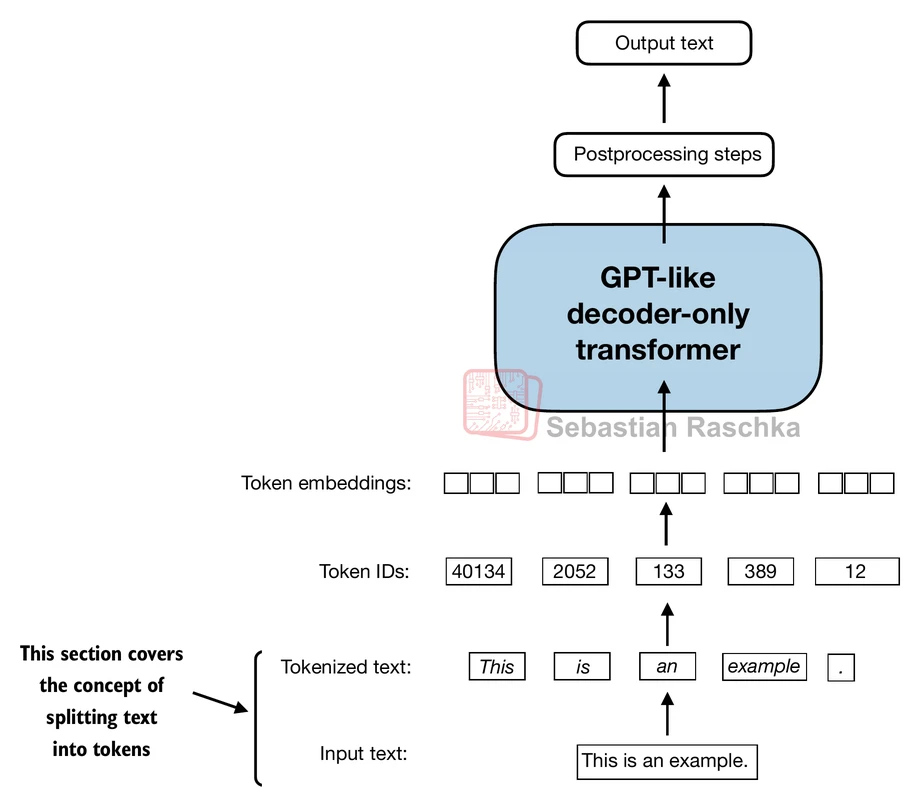

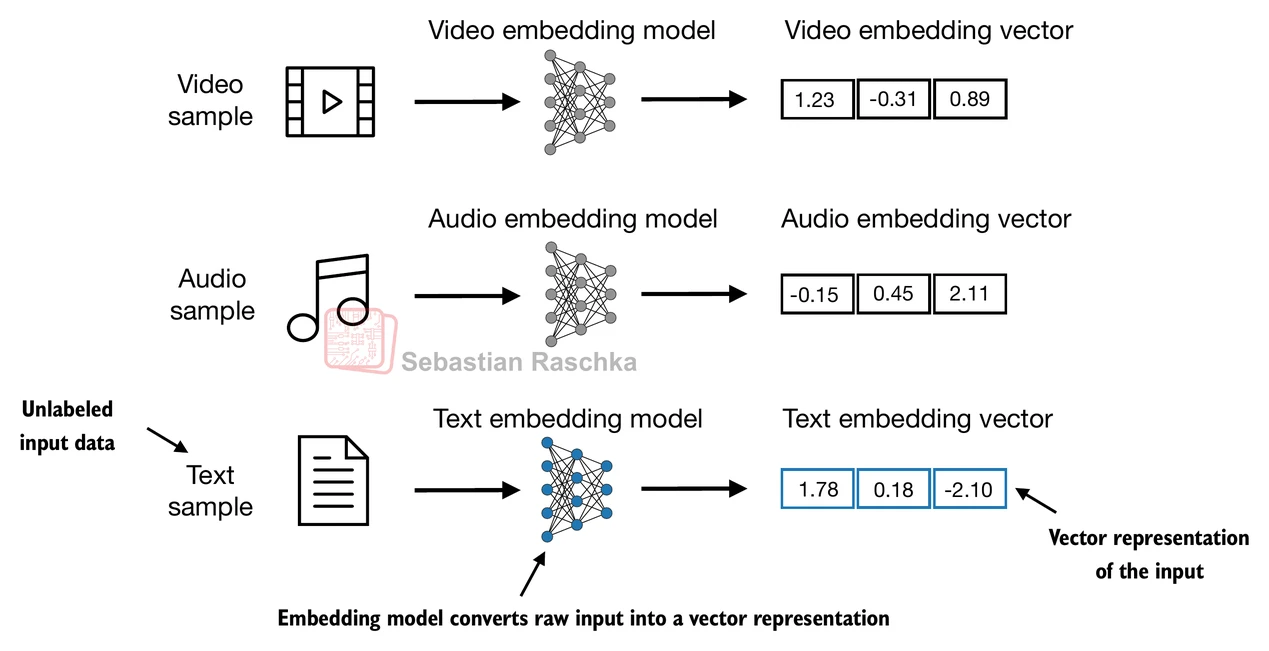

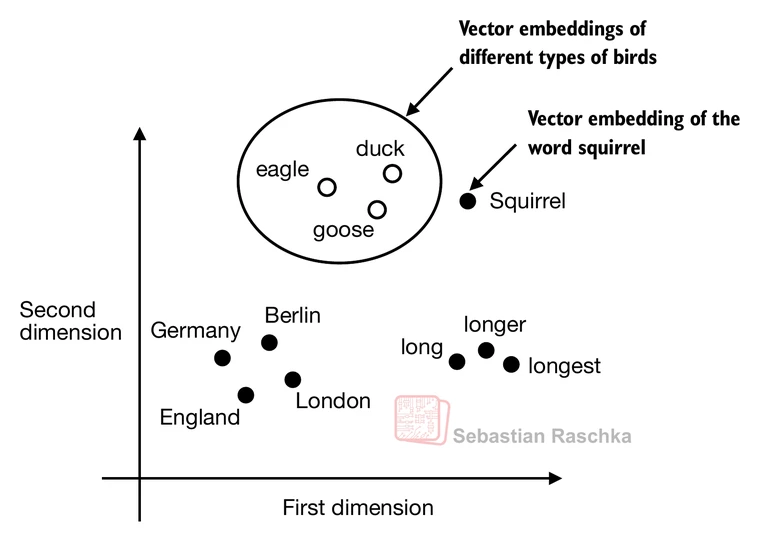

In [ ]:
#Tokenizing text
# In this section, we tokenize text, which means breaking text into smaller units, such as individual words and punctuation characters

In [3]:
import os
import urllib.request
if not os.path.exists("the-verdict.txt"):
    url= (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"
    response=requests.get(url,timeout=30)
    response.raise_for_status()
    with open(file_path,'wb')as f:
        f.write(response.content)
    # The book originally used the following code below
# However, urllib uses older protocol settings that
# can cause problems for some readers using a VPN.
# The `requests` version above is more robust
# in that regard.
"""
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/"
           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
           "the-verdict.txt")
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)
"""

'\nimport os\nimport urllib.request\n\nif not os.path.exists("the-verdict.txt"):\n    url = ("https://raw.githubusercontent.com/rasbt/"\n           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"\n           "the-verdict.txt")\n    file_path = "the-verdict.txt"\n    urllib.request.urlretrieve(url, file_path)\n'

In [4]:
with open("the-verdict.txt",'r',encoding="utf-8") as f:
    raw_text=f.read()
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [5]:
import re
text='Hello, world. This, is a test.'
result=re.split(r'(\s)',text)  #r'(\s)' 以,为分割
print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [7]:
result = re.split(r'([,.]|\s)', text)
print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [8]:
# Strip whitespace from each item and then filter out any empty strings.
result=[item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [10]:
text = "Hello, world. Is this-- a test?"
result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result=[item.strip() for item  in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


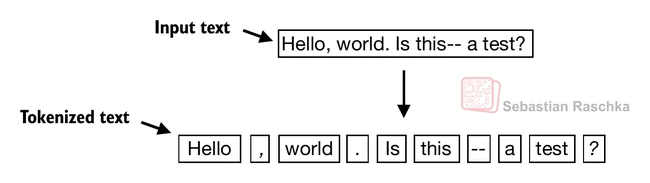

In [ ]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed=[item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])
len(preprocessed)

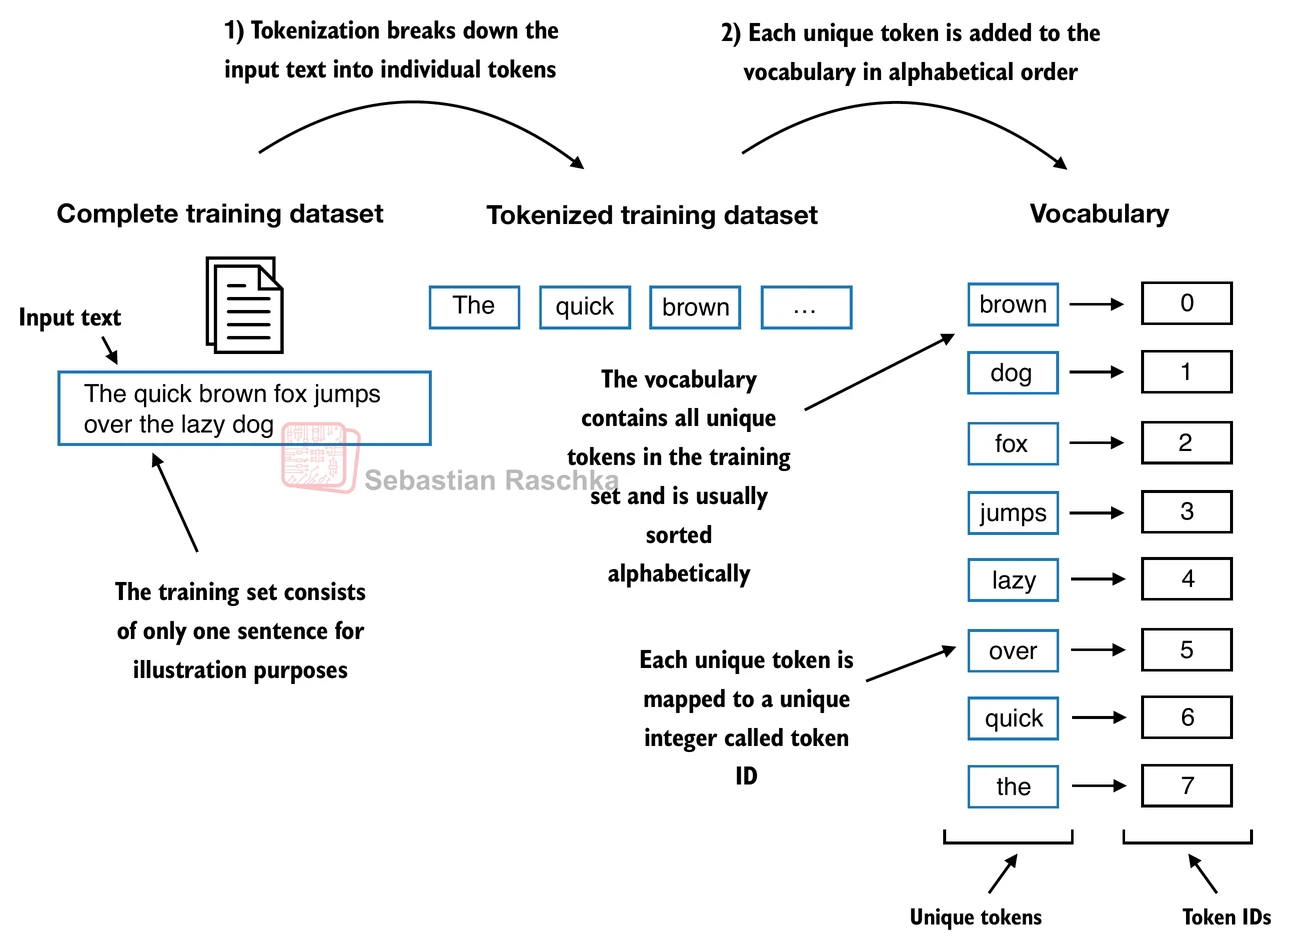

In [ ]:
#Converting tokens into token IDs

In [ ]:
all_words=sorted(set(preprocessed))
vocab_size=len(all_words)
print(vocab_size)

In [ ]:
vocab={token:integer for integer,token  in enumerate(all_words)}

In [ ]:
for i , item in enumerate(vocab.items()):
    print(item)
    if i>50:
        break

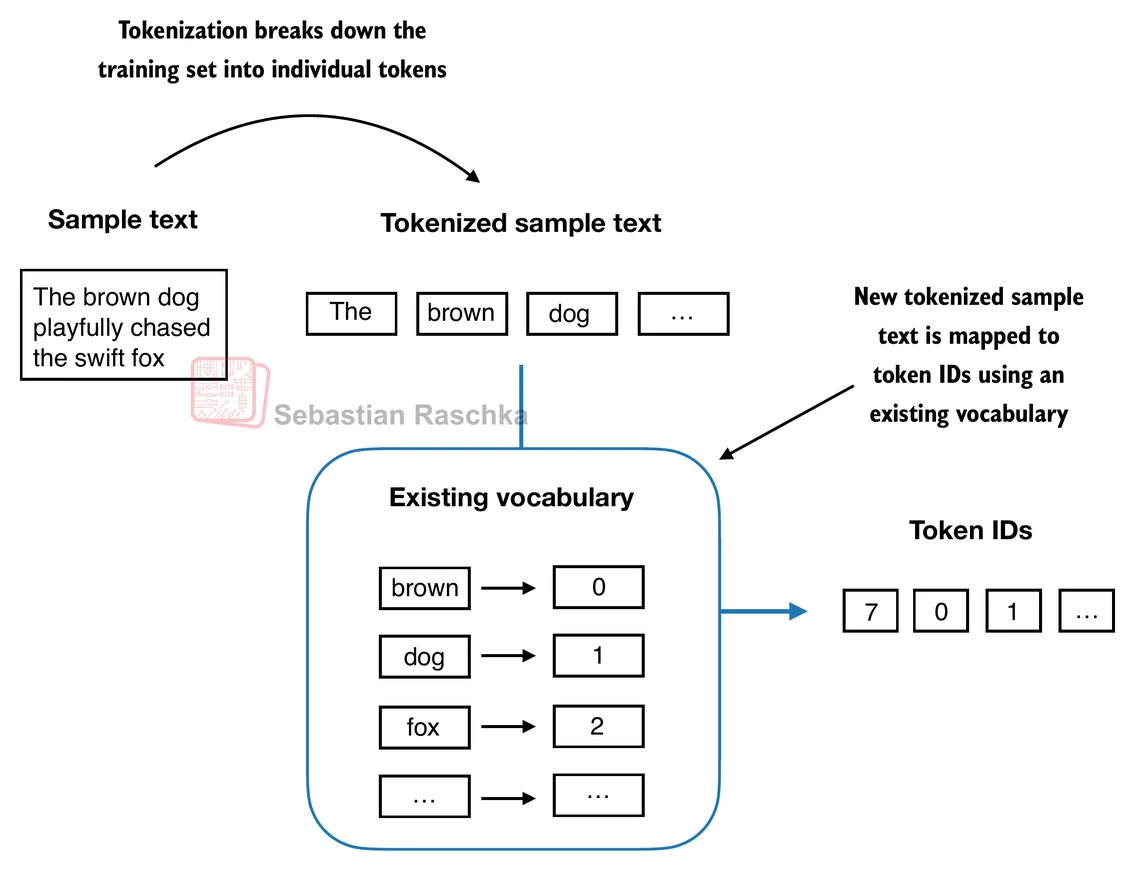

In [ ]:
class SimpleTokenzerV1:
    def __init__(self,vocab):
        self.str_to_int=vocab
        self.int_to_str={i:s for s,i in vocab.items}
    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed=[item.strip() for  item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        ids=[self.str_to_int[s] for s in preprocessed]
        return ids
    def decode(self,ids):
        text=' '.join([self.int_to_str[i] for i in ids])
        text=re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

In [ ]:
tokenizer=SimpleTokenzerV1(vocab)

In [ ]:
text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."
text = " <|endoftext|> ".join((text1, text2))
print(text)

In [ ]:
tokenizer.encode(text)

In [ ]:
tokenizer.decode(tokenizer.encode(text))

In [ ]:
#BytePair encoding    # pip install tiktoken

In [ ]:
import importlib
import tiktoken
print("tiktoken version:", importlib.metadata.version("tiktoken"))

In [ ]:
tokenizer=tiktoken.get_encoding('gpt2')

In [ ]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)
integers=tokenizer.encode(text,allowed_special={"<|endoftext|>"})
print(integers)

In [ ]:
strings=tokenizer.decode(integers)
print(strings)

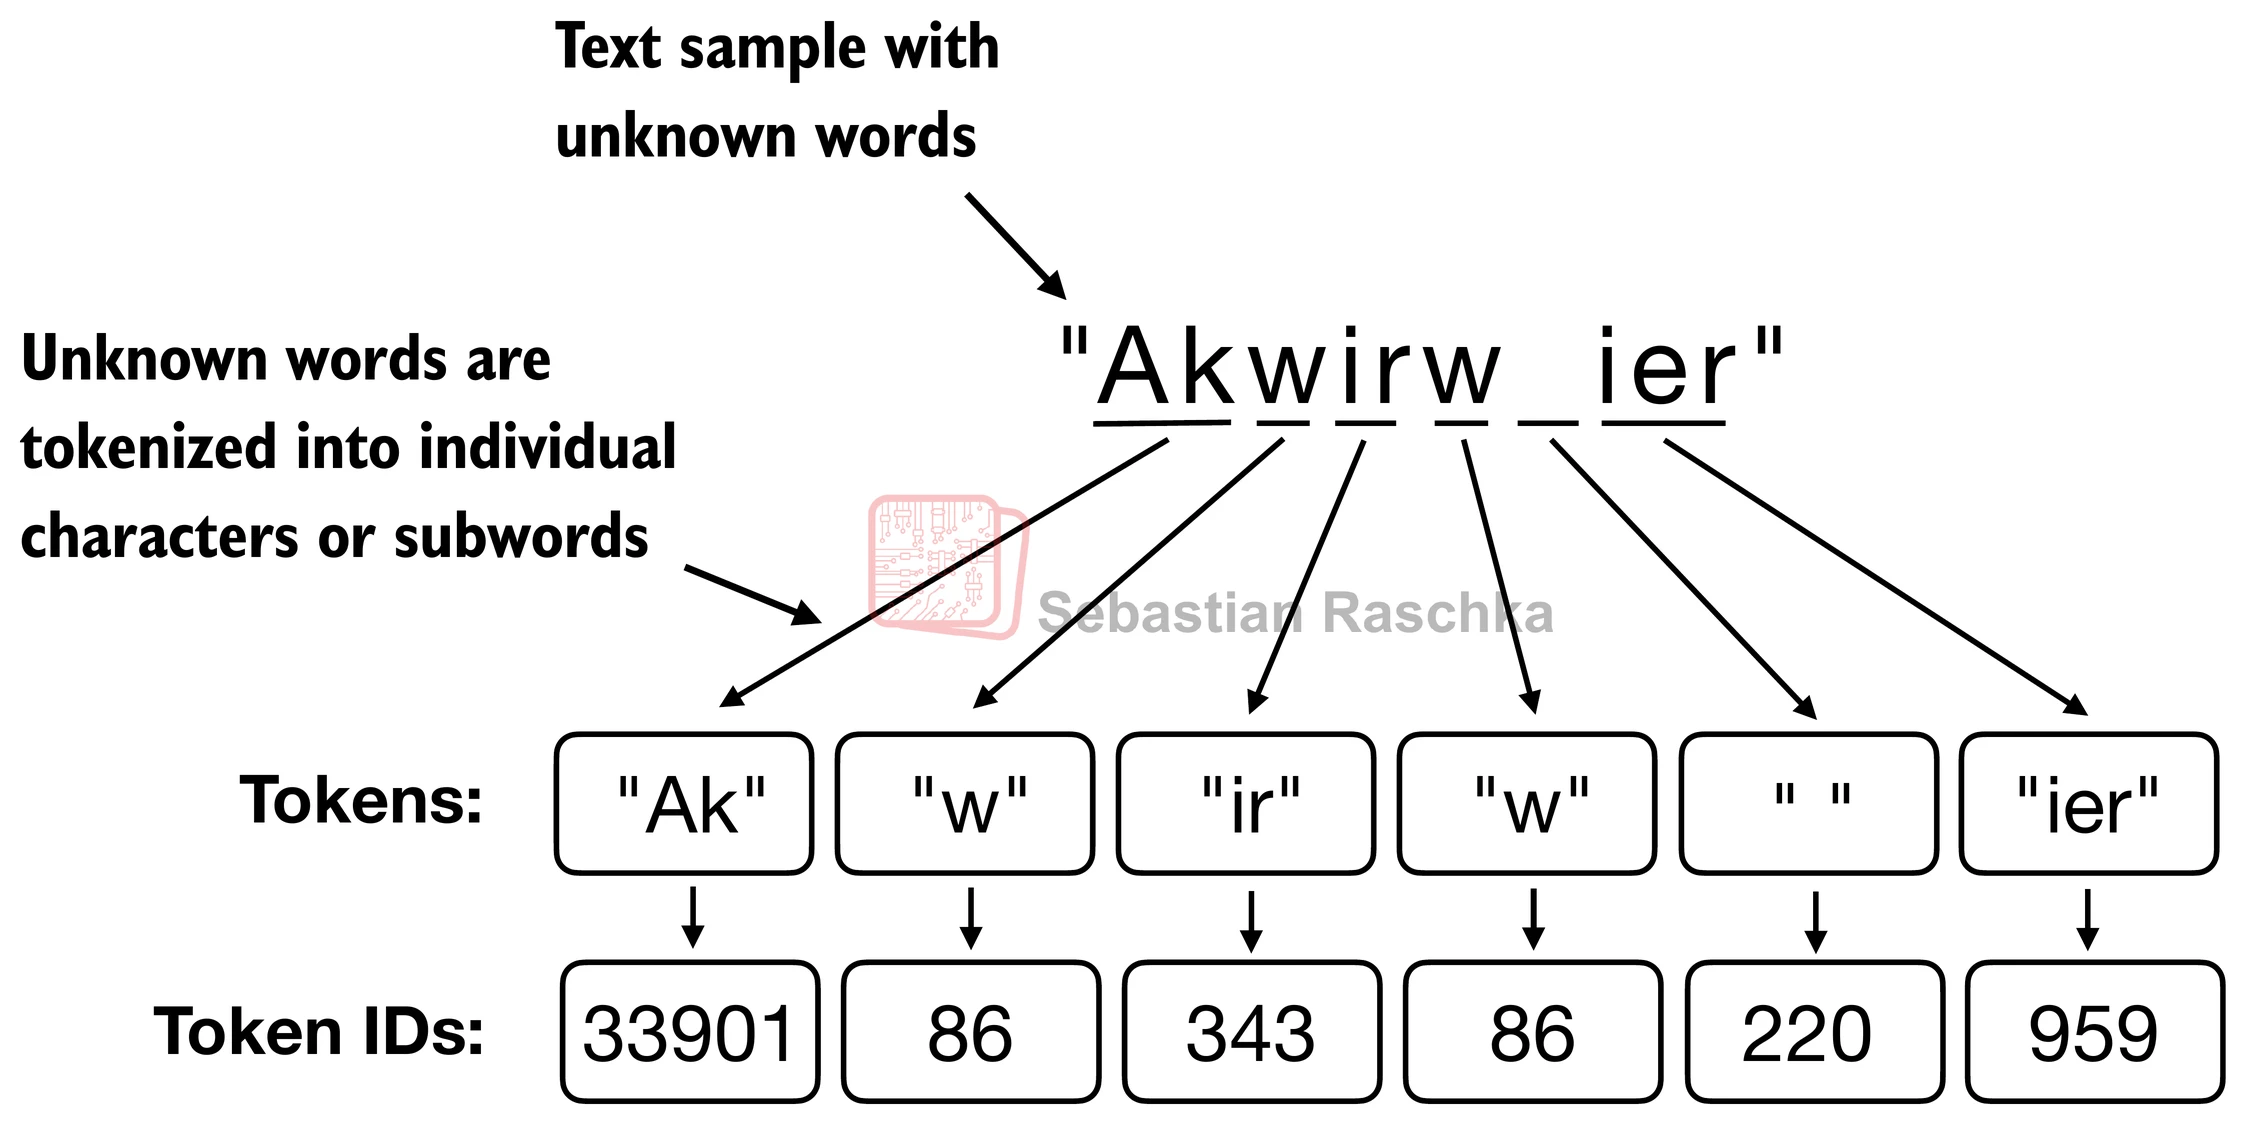

In [ ]:
#Data sampling with a sliding window

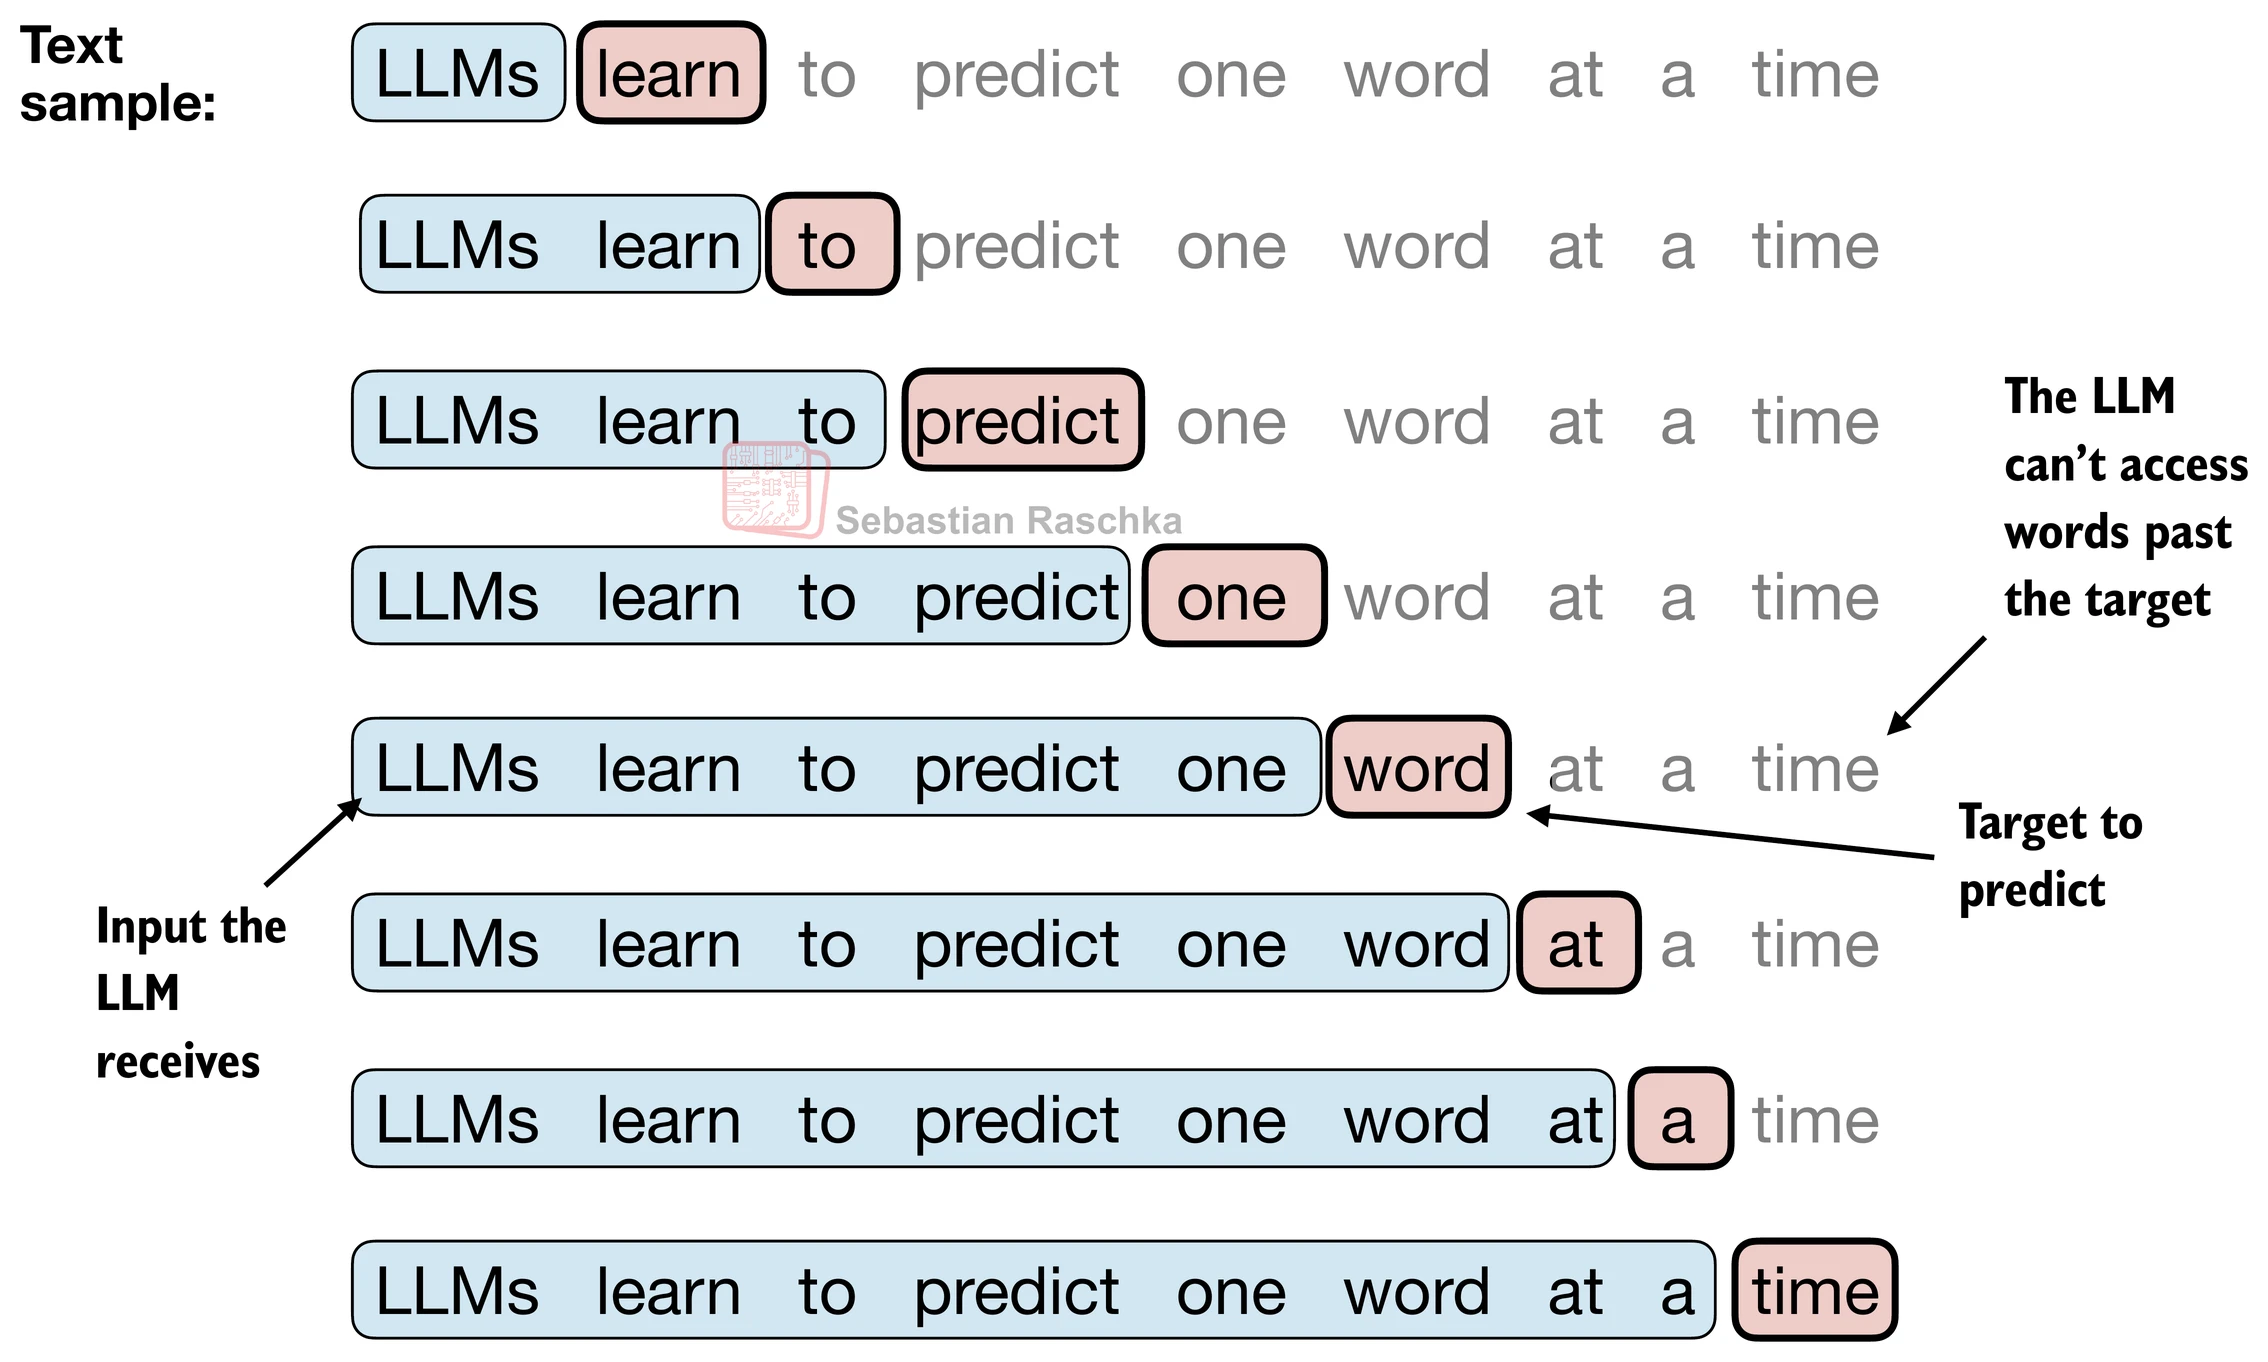

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
enc_text=tokenizer.encode(raw_text)
print(len(enc_text))

In [ ]:
enc_sample=enc_text

In [ ]:
context_size=4
x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

In [ ]:
for i in range(1, context_size+1):
    context=enc_sample[:i]
    desired=enc_sample[i]
    print(context,"----->",desired)

In [ ]:
for i in range(1,context_size):
    context=enc_sample[:i]
    desired=enc_sample[i]
    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

In [ ]:
import torch
print("PyTorch version:", torch.__version__)

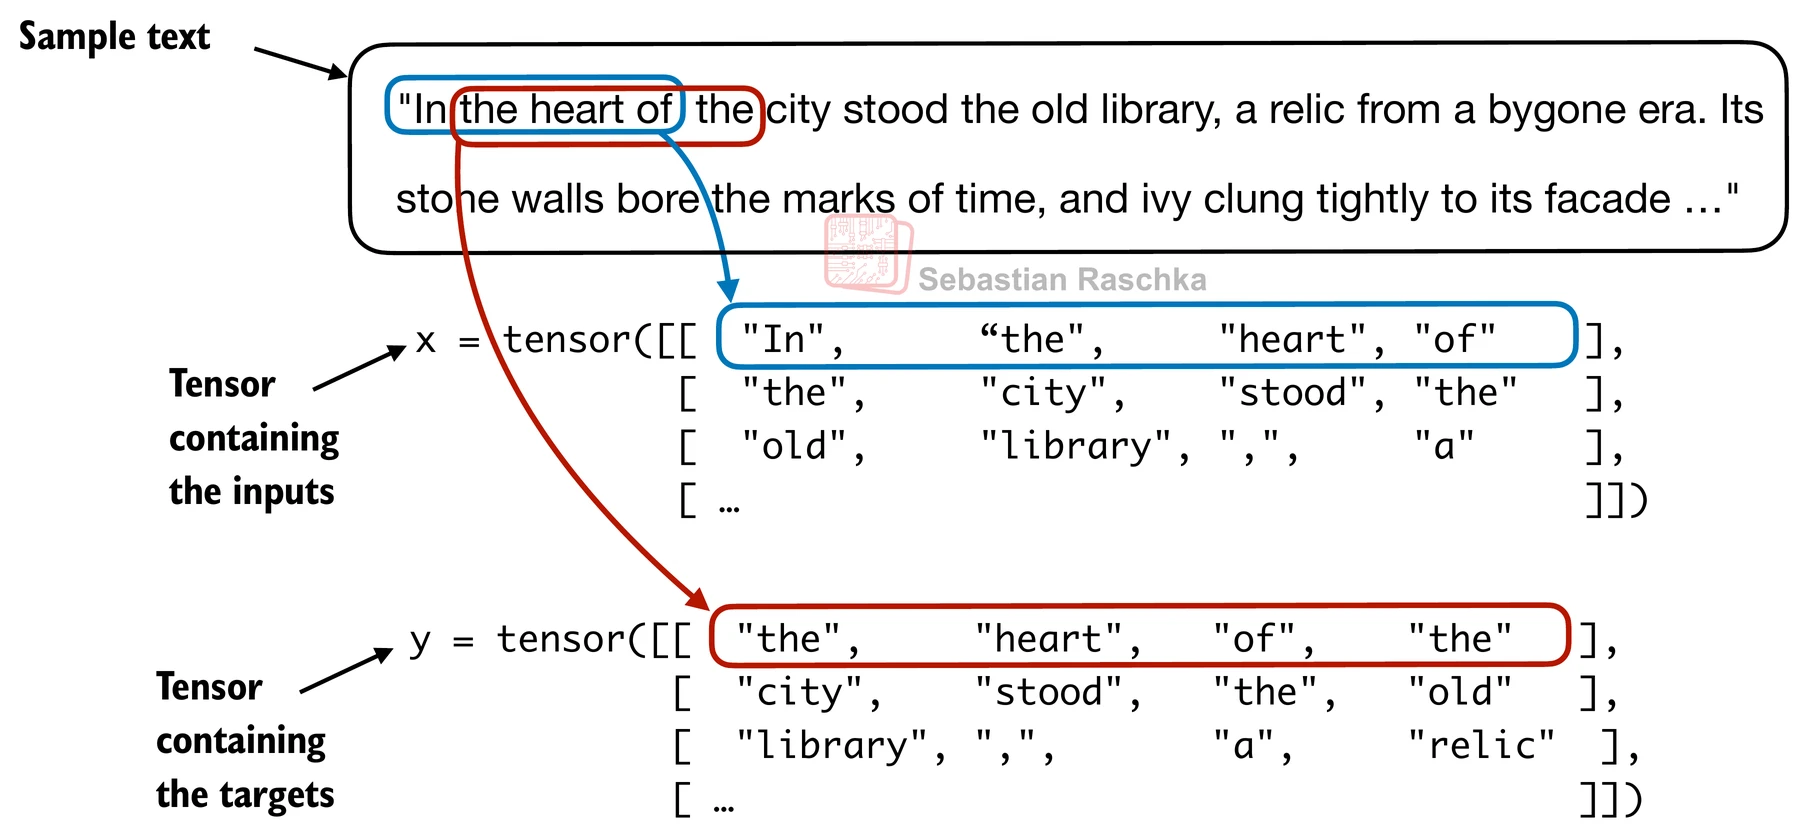

In [ ]:
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids=[]
        self.target_ids=[]
        token_ids=tokenizer.encode(txt,allowed_special={"<|endoftext|>"})
        assert  len(token_ids)>max_length,"Number of tokenized inputs must at least be equal to max_length+1"

        for i in range(0,len(token_ids)-max_length,stride):
            input_chunk=token_ids[i:i+max_length]
            target_chunk=token_ids[i+1:i+max_length+1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)
    def __getitem__(self, ids):
        return self.input_ids[ids],self.target_ids[ids]

In [ ]:
def create_dataloader_v1(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,num_workers=0):
    tokenizer=tiktoken.get_encoding("gpt2")
    dataset=GPTDatasetV1(txt,tokenizer,max_length,stride)
    dataloader=DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )
    return dataloader

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

In [ ]:
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)
data_iter=iter(dataloader)
first_batch=next(data_iter)
print(first_batch)

In [ ]:
second_batch=next(data_iter)
print(second_batch)

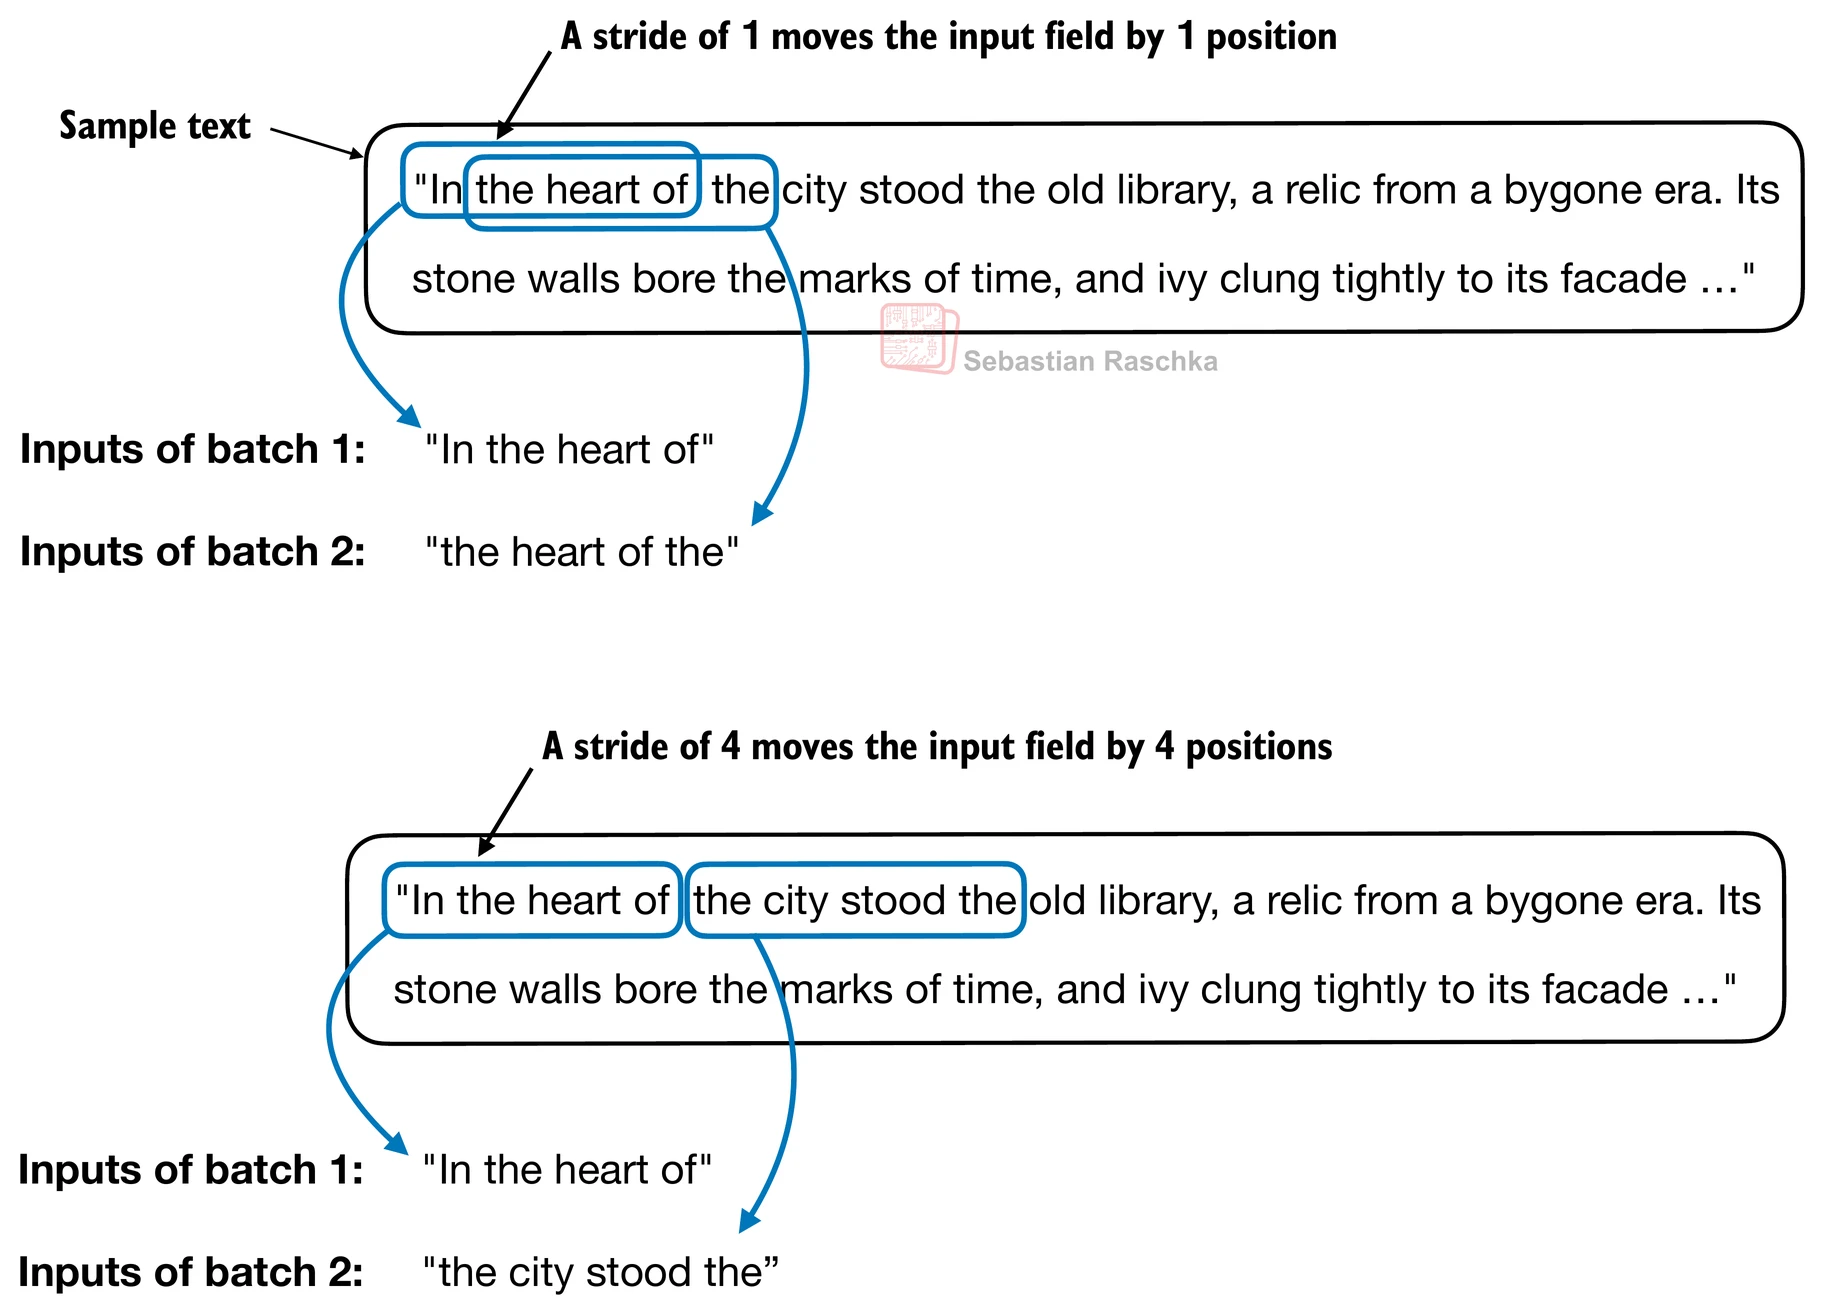

In [ ]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)
data_iter=iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("\nTargets:\n", targets)

In [ ]:
#Creating token embeddings

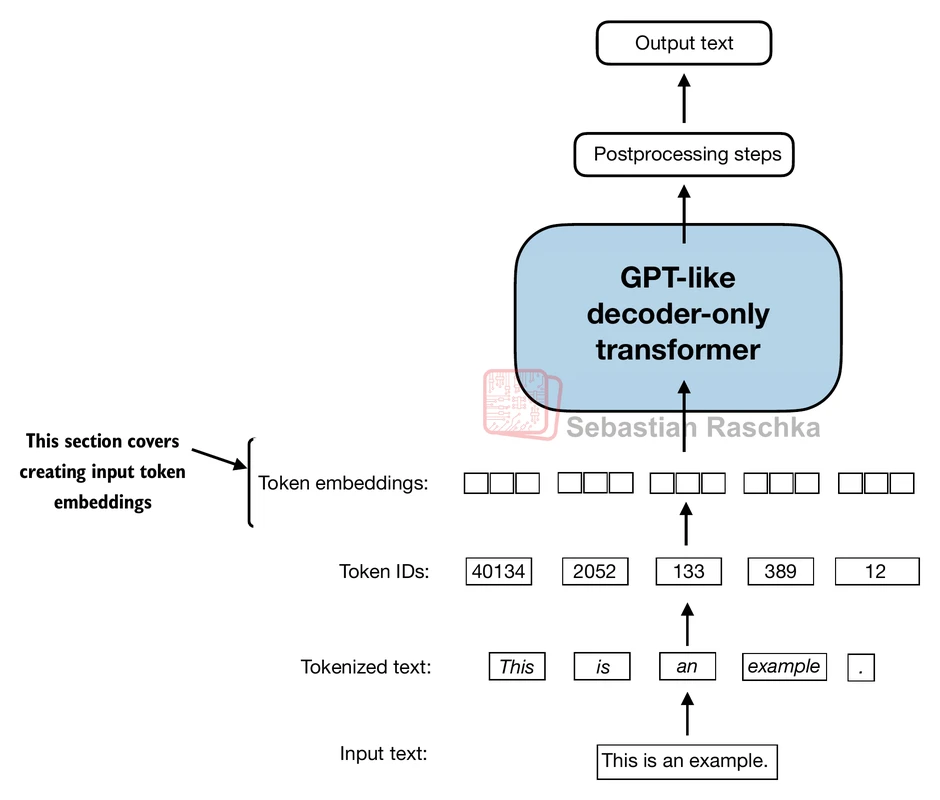

In [ ]:
input_ids = torch.tensor([2, 3, 5, 1])

In [ ]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
print(embedding_layer.weight)

In [ ]:
print(embedding_layer(torch.tensor([3])))

In [ ]:
print(embedding_layer(input_ids))

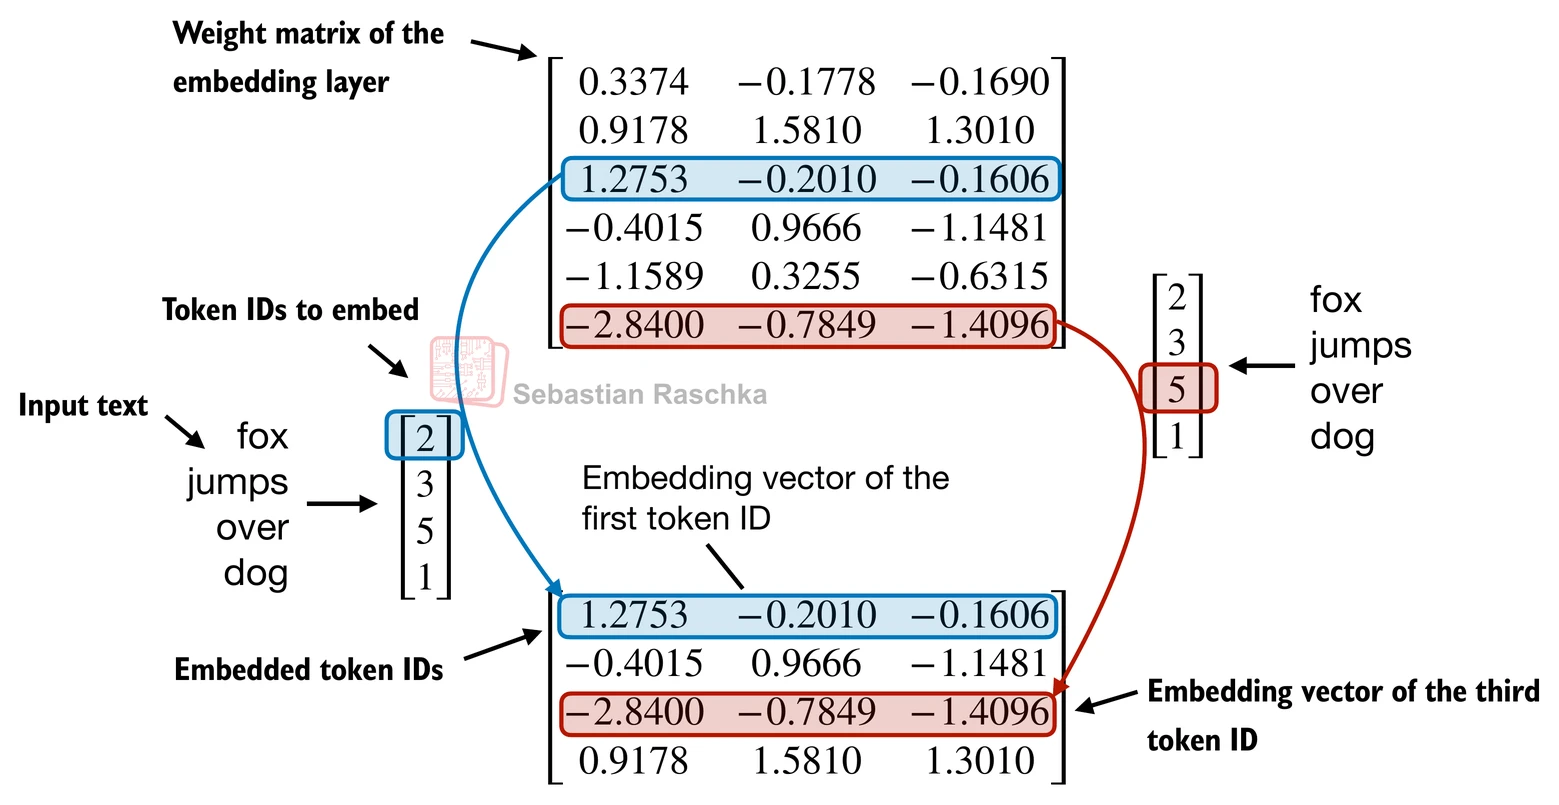

In [ ]:
#Encoding word positions

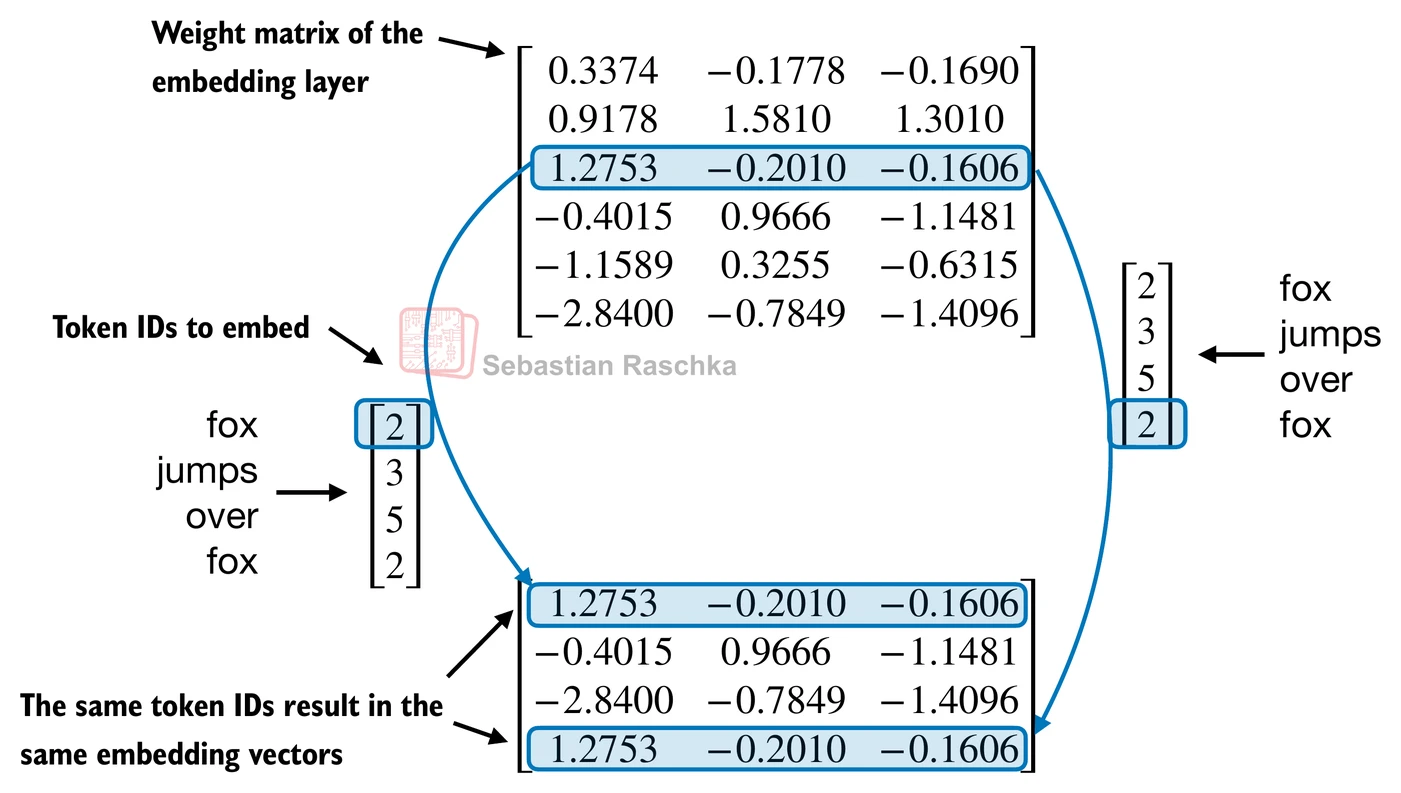

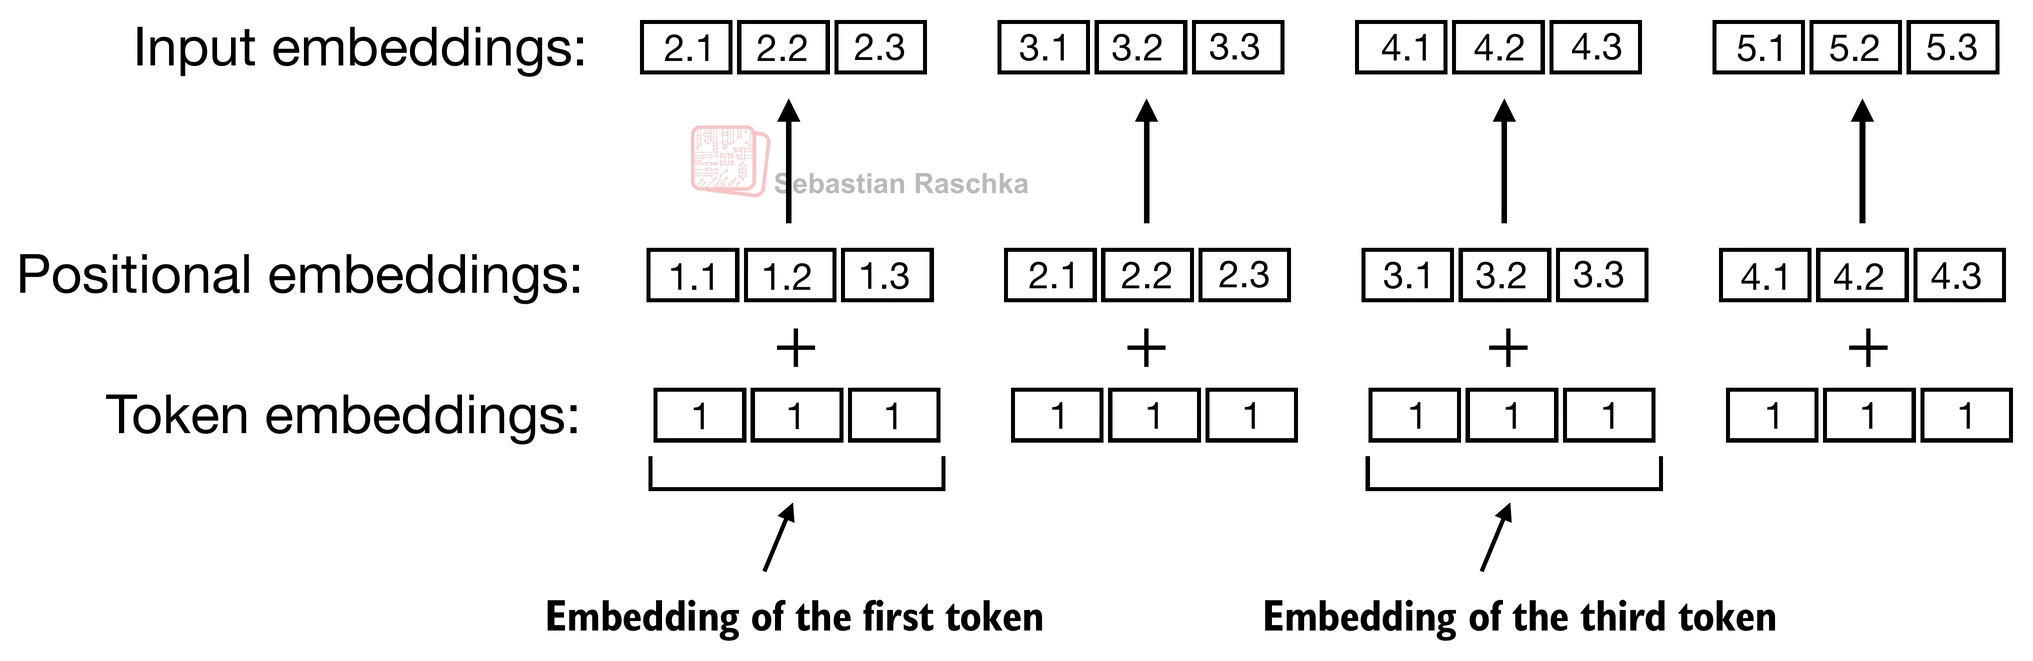

In [ ]:
vocab_size = 50257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [ ]:
max_length=4
dataloader=create_dataloader_v1(
    raw_text, batch_size=8, max_length=max_length,
    stride=max_length, shuffle=False
)
data_iter=iter(dataloader)
inputs,targets=next(data_iter)

In [ ]:
print("Token IDs:\n", inputs)
print("\nInputs shape:\n", inputs.shape)

In [ ]:
token_embeddings=token_embedding_layer(inputs)
print(token_embeddings.shape)

In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

In [ ]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)

In [ ]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)

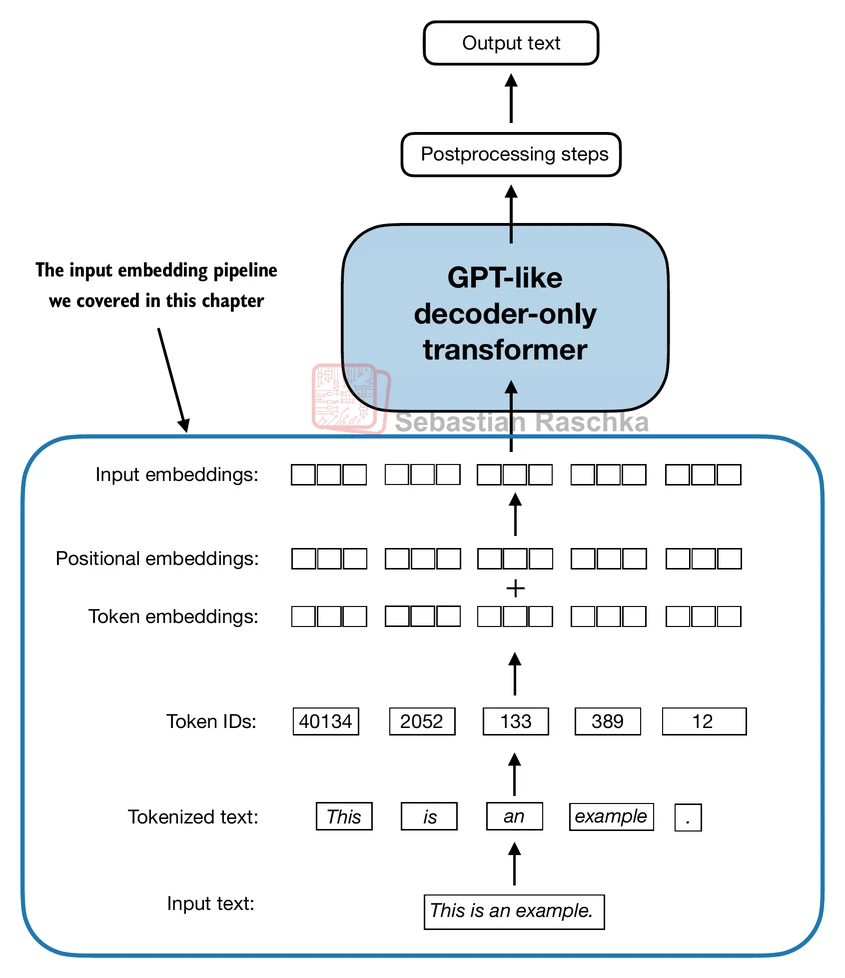